<div style="text-align: center;">
    <img src="https://user-images.githubusercontent.com/86345471/221379942-51f24819-1f76-4289-8dee-06ea69f730f6.png" alt=Main "KPI />
</di>

<hr>

**Завдання:** Реалізувати алгоритм К найближчих сусідів на одному з датасетів (н/д https://www.kaggle.com/datasets/danielfernandon/web-page-phishing-dataset), визначити його переваги та недоліки, дослідити залежність точності алгоритму від особливостей використаного датасету.

**Теорія:** Алгоритм kNN можна роздiлити на двi простi фази: навчання та класифiкацiї. Пiд час навчання алгоритм просто запам’ятовує вектори ознак спостережень та його мiтки класiв (тобто приклади). Також задається параметр алгоритму k, який задає число «сусiдiв», якi будуть використовуватися пiд час класифiкацiї.

<hr>

### 1. Імпорт бібліотек

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_auc_score  

### 2. Завантаження даних

In [2]:
dataset = pd.read_csv('./web-page-phishing.csv')
dataset.shape

(100077, 20)

### 3. Огляд даних

In [3]:
dataset.sample(5)

,url_length,n_dots,n_hypens,n_underline,n_slash,n_questionmark,n_equal,n_at,n_and,n_exclamation,n_space,n_tilde,n_comma,n_plus,n_asterisk,n_hastag,n_dollar,n_percent,n_redirection,phishing
85795,14,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
42907,19,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0
81075,28,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
2630,35,2,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
7361,33,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1


In [4]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100077 entries, 0 to 100076
Data columns (total 20 columns):
 #   Column          Non-Null Count   Dtype
---  ------          --------------   -----
 0   url_length      100077 non-null  int64
 1   n_dots          100077 non-null  int64
 2   n_hypens        100077 non-null  int64
 3   n_underline     100077 non-null  int64
 4   n_slash         100077 non-null  int64
 5   n_questionmark  100077 non-null  int64
 6   n_equal         100077 non-null  int64
 7   n_at            100077 non-null  int64
 8   n_and           100077 non-null  int64
 9   n_exclamation   100077 non-null  int64
 10  n_space         100077 non-null  int64
 11  n_tilde         100077 non-null  int64
 12  n_comma         100077 non-null  int64
 13  n_plus          100077 non-null  int64
 14  n_asterisk      100077 non-null  int64
 15  n_hastag        100077 non-null  int64
 16  n_dollar        100077 non-null  int64
 17  n_percent       100077 non-null  int64
 18  n_re

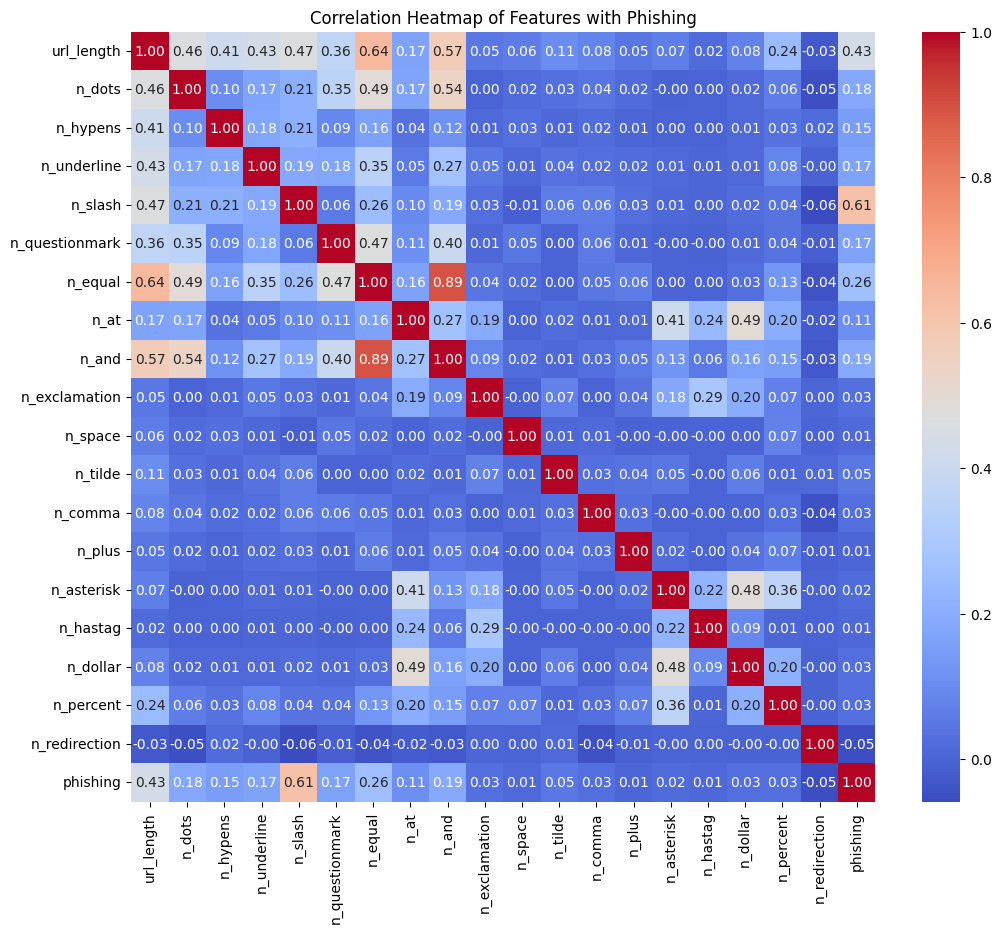

In [5]:
plt.figure(figsize=(12, 10))
correlation_matrix = dataset.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Heatmap of Features with Phishing')
plt.show()

### 4. Попередня обробка даних¶

In [6]:
dataset.dropna()
dataset.shape

(100077, 20)

### 5. Розділення на навчальні та тестові дані

In [7]:
X = dataset.drop(['phishing'], axis = 1)
y = dataset['phishing']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=2)

### 6. Стандартизація даних

In [8]:
scaler = StandardScaler()
scaler.fit(X_train)
scaled_X_train = scaler.transform(X_train) 
scaled_X_test = scaler.transform(X_test)

### 7. Навчання методом K-найближчих сусідів

In [9]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(scaled_X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


### 8. Прогнозування

In [10]:
pred = knn.predict(scaled_X_test)

### 9. Оцінка моделі

In [11]:
report = classification_report(y_test, pred)
conf_matrix = confusion_matrix(y_test, pred)

print("Classification Report:\n", report)
print("Confusion Matrix:\n", conf_matrix)

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.93      0.92     12783
           1       0.87      0.83      0.85      7233

    accuracy                           0.89     20016
   macro avg       0.88      0.88      0.88     20016
weighted avg       0.89      0.89      0.89     20016

Confusion Matrix:
 [[11850   933]
 [ 1253  5980]]


### 10. Візуалізація результатів

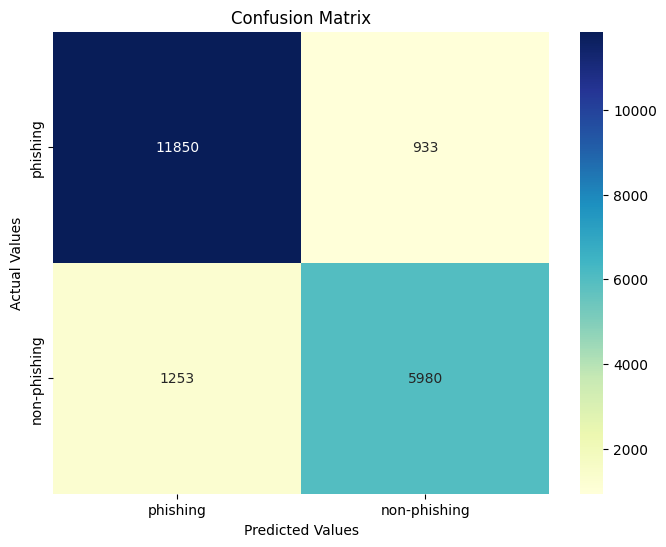

In [12]:
class_names = ['phishing', 'non-phishing']

plt.figure(figsize=(8, 6))

sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='YlGnBu', xticklabels=class_names, yticklabels=class_names)

plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.title('Confusion Matrix')

plt.show()

<hr>

### * Пошук оптимальних параметрів для покращення точності моделі

#### 1. Дослідження оптимального значення параметра K

- За середньою помилкою на тестовому наборі:

In [ ]:
error_rate = []

for i in range(1, 30):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(scaled_X_train, y_train)
    pred_i = knn.predict(scaled_X_test)
    error_rate.append(np.mean(pred_i != y_test))

    if np.mean(pred_i != y_test) <= min(error_rate):
        optima_k = i
    else:
        continue

- Графік залежності показника помилки від K:

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(range(1, 30), error_rate, marker='o', markersize=10)
plt.title('Error Rate vs. K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')
plt.grid()

#### 2. Налаштування моделі з оптимальним K

- Навчання методом K-найближчих сусідів

In [ ]:
knn = KNeighborsClassifier(n_neighbors=optima_k)
knn.fit(scaled_X_train,y_train)

- Прогнозування

In [ ]:
pred = knn.predict(scaled_X_test)

- Оцінка моделі

In [ ]:
report = classification_report(y_test, pred)
conf_matrix = confusion_matrix(y_test, pred)

print("Classification Report:\n", report)
print("Confusion Matrix:\n", conf_matrix)

#### 3. Аналіз продуктивності моделі

- Побудова ROC-кривої для аналізу

In [ ]:
svc_disp=RocCurveDisplay.from_predictions(y_test, pred)
plt.show()

In [ ]:
print("Area Under the Curve:", round(roc_auc_score(y_test, pred), 3))

- Побудова Precision-Recall кривої

In [ ]:
svc_disp=PrecisionRecallDisplay.from_predictions(y_test, pred)
plt.show()

<hr>

### * Ознаки притаманні алгоритму kNN

**Переваги**

•	Стiйкiсть до викидiв й аномальних значень, оскiльки ймовiрнiсть попадання записiв, що мiстять їх, до k-найближчих сусiдiв мала. Якщо ж це сталося, то вплив на голосування (особливо зважене) швидше за все, буде незначним, а отже, малим буде i вплив на результати класифiкацiї; 

•	Програмна реалiзацiя алгоритму доволi проста;

•	Результати роботи алгоритму легко пiддаються iнтерпретацiї;

•	Логiка роботи алгоритму зрозумiла експертам у рiзних галузях. 

**Недолiки** 

•	Цей метод не створює будь-яких моделей, якi узагальнюють попереднiй досвiд, а iнтерес можуть становити й самi правила класифiкацiї;

•	Пiд час класифiкацiї об’єкта використовуються всi доступнi данi, тому метод kNN є досить витратним, особливо в разi великих обсягiв даних;

•	Висока трудомiсткiсть через необхiднiсть обчислення вiдстаней до всiх прикладiв;

•	Пiдвищенi вимоги до репрезентативностi вихiдних даних.

<u>**Застосування**<u>

Алгоритм kNN може застосовуватися практично в усiх завданнях класифiкацiї, особливо в разi, коли оцiнити параметри ймовiрнiсного розподiлу даних складно чи неможливо. Незважаючи на те, що алгоритм досить простий для розуміння та реалізації, він знайшов широке застосування в таких областях як рекомендаційні системи, семантичний пошук та виявлення аномалій. Однак для його застосування потрібно мати можливість зберегти весь навчальний набір у пам'яті, а виконання класифікацій може бути обчислювально дорогим, оскільки алгоритм аналізує всі точки даних для кожної класифікації. З цих причин kNN краще застосовувати до невеликих наборів даних, які не мають величезного набору ознак.

Алгоритм kNN є "пам'яттєвим" методом (зберігає всі дані навчання), тому розмір датасету прямо пропорційно впливає на його точність. Зі збільшенням обсягу даних точність алгоритму може покращуватися, оскільки модель має більше прикладів для пошуку найближчих сусідів. Проте зростає і час обробки, оскільки алгоритм обчислює відстань від нового зразка до всіх навчальних даних.